In [1]:
import pandas as pd

In [2]:
food_data = pd.read_csv("food_coded.csv")

In [3]:
food_data.head()

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4,940.0,500,Softball,4,2,760,190


In [8]:
food_data["comfort_food_reasons_coded"].value_counts()

comfort_food_reasons_coded
2.0    49
1.0    22
3.0    18
9.0     5
5.0     4
4.0     3
7.0     3
6.0     1
8.0     1
Name: count, dtype: int64

## Chart one comfort food

In [9]:
mapping = {1: "stress",
           2: "boredom",
           3: "depression/sadness",
           4: "hunger",
           5: "laziness",
           6: "cold weather",
           7: "happiness",
           8: "watching tv",
           9: "none"}

comfort_food_reasons = food_data["comfort_food_reasons_coded"].map(mapping)


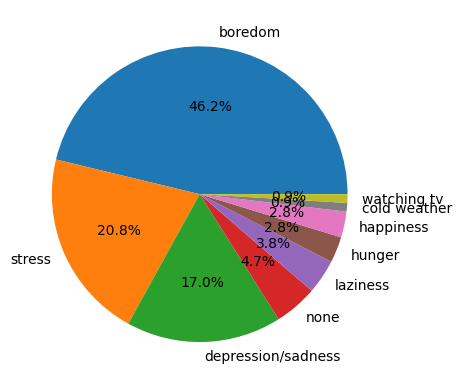

In [14]:
import matplotlib.pyplot as plt
comfort_food_reasons.value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.show()

CHart 2 Income vs vegetables
 

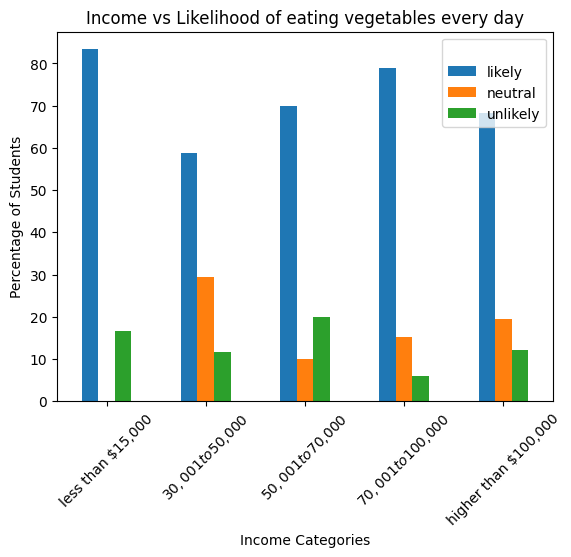

In [28]:

mapping_income = {1: "less than $15,000",
                  2: "$15,001 to $30,000",
                  3: "$30,001 to $50,000",
                  4: "$50,001 to $70,000",
                  5: "$70,001 to $100,000",
                  6: "higher than $100,000"}

mapping_veg = {1: "very unlikely",
                   2: "unlikely",
                   3: "neutral",
                   4: "likely",
                   5: "very likely"}


data_short = food_data[["income", "veggies_day"]]
data_short["income"] = data_short["income"].map(mapping_income)
data_short["veggies_day"] = data_short["veggies_day"].map(mapping_veg)
data_short.loc[data_short["veggies_day"] == "very likely", "veggies_day"] = "likely"
data_short.loc[data_short["veggies_day"] == "very unlikely", "veggies_day"] = "unlikely"
grouped_percent = pd.crosstab(
    data_short["income"],
    data_short["veggies_day"],
    normalize="index"   # normalise par income
) * 100

order = [
    "less than $15,000",
    "$30,001 to $50,000",
    "$50,001 to $70,000",
    "$70,001 to $100,000",
    "higher than $100,000"
]

grouped_percent = grouped_percent.reindex(order)
grouped_percent.plot(kind="bar")
plt.xlabel("Income Categories")
plt.ylabel("Percentage of Students")
plt.title("Income vs Likelihood of eating vegetables every day")
plt.legend(title=" ")
plt.xticks(rotation=45)
plt.show()



chart 3 - cook

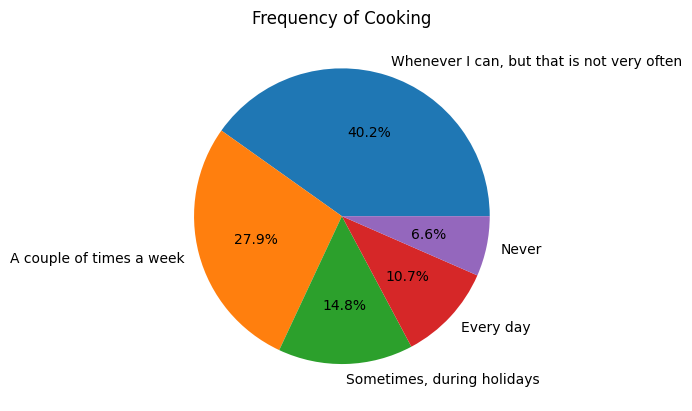

In [30]:


cook_mapping = {1: "Every day",
                2: "A couple of times a week",
                3: "Whenever I can, but that is not very often",
                4: "Sometimes, during holidays",
                5: "Never"}

data_cook = food_data["cook"]
data_cook = data_cook.map(cook_mapping)
data_cook.value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Frequency of Cooking")
plt.show()

chart 4 Eating changes since college

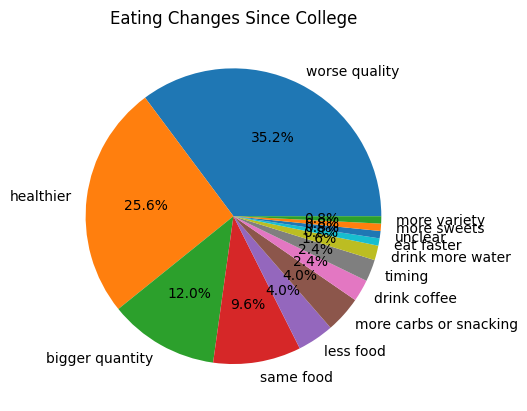

In [34]:

change_mapping = {1: "eat faster",
                  2: "bigger quantity",
                  3: "worse quality",
                  4: "same food",
                  5: "healthier",
                  6: "unclear",
                  7: "drink coffee",
                  8: "less food",
                  9: "more sweets",
                  10: "timing",
                  11: "more carbs or snacking",
                  12: "drink more water",
                  13: "more variety"}

data_change = food_data["eating_changes_coded1"]
data_change = data_change.map(change_mapping)
data_change.value_counts().plot(kind="pie", autopct="%1.1f%%", labeldistance=1.1)
plt.title("Eating Changes Since College")
plt.xticks(rotation=45)
plt.show()

Chart 5 Eating out frequency vs on out of campus

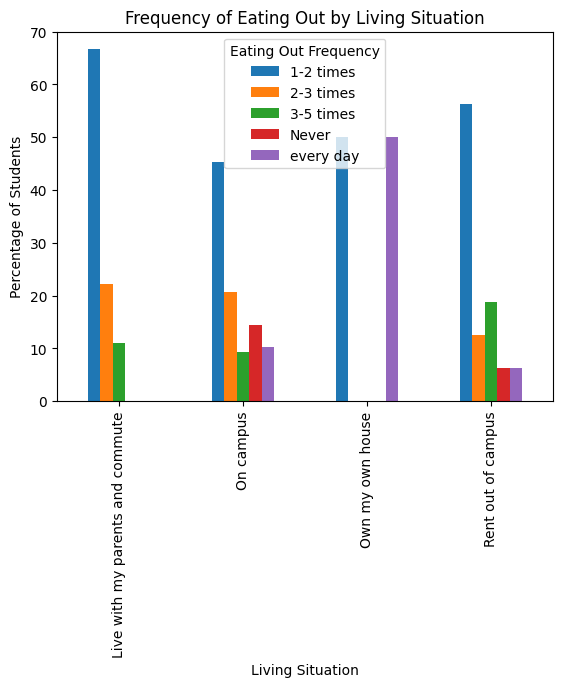

In [37]:

eat_out_mapping = {1: "Never",
                   2: "1-2 times",
                   3: "2-3 times",
                   4: "3-5 times",
                   5: "every day"}

on_campus_mapping = {1: "On campus",
                     2: "Rent out of campus",
                     3: "Live with my parents and commute",
                     4: "Own my own house"}

data_eat_out = food_data[["eating_out","on_off_campus"]]
data_eat_out["eating_out"] = data_eat_out["eating_out"].map(eat_out_mapping)
data_eat_out["on_off_campus"] = data_eat_out["on_off_campus"].map(on_campus_mapping)
grouped_percent_eat_out = pd.crosstab(data_eat_out["on_off_campus"],
    data_eat_out["eating_out"],
    normalize="index"   # normalise par eating out frequency
) * 100
grouped_percent_eat_out.plot(kind="bar")
plt.xlabel("Living Situation")
plt.ylabel("Percentage of Students")
plt.legend(title="Eating Out Frequency")
plt.title("Frequency of Eating Out by Living Situation")
plt.show()